In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Amit Dubli\VS code\Assignment 4\data\q2_customers.csv")

In [3]:
# Displaing first few rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [5]:
# Converting back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


In [6]:
pip install --upgrade threadpoolctl

Note: you may need to restart the kernel to use updated packages.


C:\Users\Amit D\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


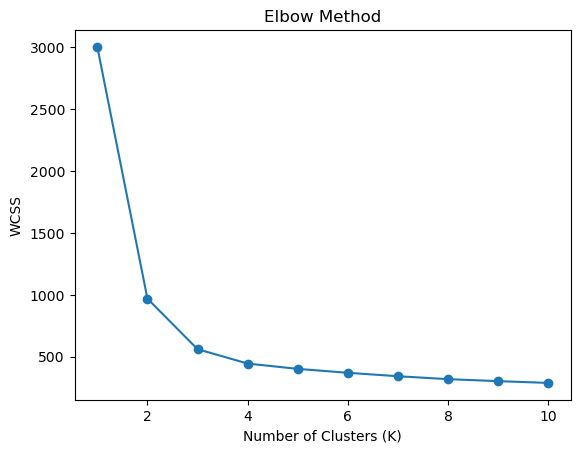

In [7]:
# tryng different numbers of clusters and choosing the one where adding more clusters doesn’t improve the model much using Elbow method.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

From elbow method elbow occurs at K = 3, where the reduction in WCSS slows significantly, indicating an optimal balance between cluster compactness and simplicity

In [8]:
# Grouping the customers into 3 segments and showing the typical profile of each group using centroid

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_df)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # excluding the cluster column
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [9]:
# Principal Component Analysis (PCA) for Dimensionality Reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],  # exclude cluster
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


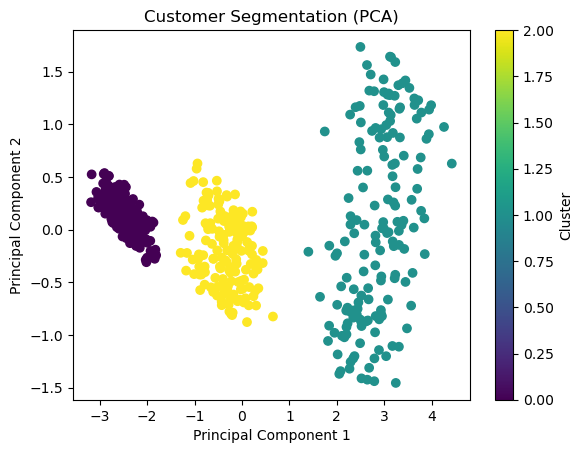

In [10]:
plt.figure()

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['cluster']
)

plt.title('Customer Segmentation (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(label='Cluster')
plt.show()

The plot shows three clearly separated clusters, mainly divided along Principal Component 1 (PC1).
This means PC1 is the strongest factor differentiating customers.
Cluster on the left (purple) - customers are very similar as it i tightly grouped.
Middle cluster (yellow) - moderately spread - average or mixed-type customers.
Right cluster (green)- more spread out - diverse group with varying behavior.
The clear gaps between clusters indicate that K-Means has done a good job and the segmentation is meaningful.